<a href="https://colab.research.google.com/github/cdiegor/OtimizacaoCombinatoria/blob/main/VRP_BC_BP_Pyomo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# VRP — Branch-and-Cut (min-cut) e Branch-and-Price (Pyomo, CBC)



In [49]:
!pip install pyomo networkx
!apt-get install -y -qq glpk-utils
!apt-get install -y -qq coinor-cbc

In [ ]:

import math, time, random
from typing import List, Tuple, Dict
from dataclasses import dataclass
from collections import deque, defaultdict

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

try:
    import pyomo.environ as pyo
except Exception as e:
    print("Pyomo não está instalado neste ambiente:", e)

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True

random.seed(42)
np.random.seed(42)

def get_solver(max_seconds: int = 300):
    """Tenta CBC e, se não houver, GLPK. Retorna (nome, objeto) ou (None, None)."""
    try:
        opt = pyo.SolverFactory('cbc')
        if opt.available():
            try: opt.options['seconds'] = int(max_seconds)
            except Exception: pass
            return 'cbc', opt
    except Exception:
        pass
    try:
        opt = pyo.SolverFactory('glpk')
        if opt.available():
            try: opt.options['tmlim'] = int(max_seconds)
            except Exception: pass
            return 'glpk', opt
    except Exception:
        pass
    print("Nenhum solver disponível (cbc/glpk).")
    return None, None


## Instâncias e visualização

[0 3 1 3 2 5 1 2 4 1 4 2 1 1 2 1 2 1 2 1 3 6 6 2 1 3 1 1 1 1 3]


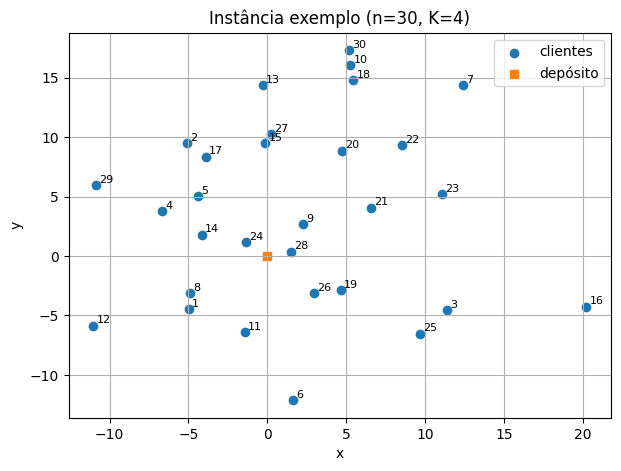

In [110]:

@dataclass
class VRPInstance:
    n: int         # número de clientes
    K: int         # número de veículos
    coords: np.ndarray  # (n+1, 2) — nó 0 é o depósito
    dist: np.array    # matriz (n+1)x(n+1) de distâncias
    Q: int
    d: list

def make_instance(n: int=20, K: int=3, sigma: float=8.0) -> 'VRPInstance':
    depot = np.array([[0.0, 0.0]])
    clients = np.random.normal(loc=0.0, scale=sigma, size=(n,2))
    coords = np.vstack([depot, clients])
    diff = coords[:,None,:] - coords[None,:,:]
    dist = np.sqrt(np.sum(diff*diff, axis=2))
    Q = len(clients)//3
    d = np.append(np.array([0]), np.random.geometric(p=1/2, size=n))
    print(d)
    return VRPInstance(n=n, K=K, coords=coords, dist=dist, Q=Q, d=d)

def plot_instance(inst: 'VRPInstance', title="Instância VRP (m-TSP)"):
    xs, ys = inst.coords[:,0], inst.coords[:,1]
    plt.figure()
    plt.scatter(xs[1:], ys[1:], label="clientes")
    plt.scatter([xs[0]],[ys[0]], marker='s', label="depósito")
    for i in range(1, inst.n+1):
        plt.text(xs[i]+0.2, ys[i]+0.2, str(i), fontsize=8)
    plt.title(title); plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.show()

def plot_routes(inst, routes, title="Rotas"):
    xs, ys = inst.coords[:,0], inst.coords[:,1]
    plt.figure(figsize=(8, 6))

    # Plota clientes e depósito
    plt.scatter(xs[1:], ys[1:], c='steelblue', s=80, label="Clientes", zorder=2)
    plt.scatter([xs[0]],[ys[0]], c='orange', marker='s', s=100, label="Depósito", zorder=3)

    # Anotações dos IDs
    for i in range(1, inst.n+1):
        plt.text(xs[i]+0.4, ys[i]+0.4, str(i), fontsize=9, color='black')

    # Cores distintas para cada veículo (rota)
    colors = plt.cm.tab10(np.linspace(0, 1, len(routes)))

    for idx, r in enumerate(routes):
        # r é uma lista de nós, ex: [0, 5, 10, 0]
        r_xs = [xs[node] for node in r]
        r_ys = [ys[node] for node in r]

        # Plota a linha contínua da rota
        plt.plot(r_xs, r_ys, c=colors[idx], linewidth=2, label=f"Veículo {idx+1}", zorder=1)

        # Opcional: setas para direção
        # for u, v in zip(r[:-1], r[1:]):
        #    plt.arrow(xs[u], ys[u], (xs[v]-xs[u]), (ys[v]-ys[u]),
        #              length_includes_head=True, head_width=0.5, color=colors[idx])

    plt.title(title)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.legend()
    plt.grid(True, alpha=0.5)
    plt.show()

inst = make_instance(n=30, K=4, sigma=8.0)
plot_instance(inst, "Instância exemplo (n=30, K=4)")



## Parte I — Branch-and-Cut com **out-cuts** via **min-cut**

Modelo base (m-TSP por arcos; graus em clientes = 1; $K$ saídas/entradas no depósito).  
Os **out-cuts** $\sum_{i\in S}\sum_{j\notin S} x_{ij} \ge 1$ são separados resolvendo **min-cut** $(0\to t)$ para cada cliente $t$.  
Agora com **deduplicação de cortes**, **tolerâncias** e opção de **laço em LP**.


Modelo Matemático: Branch-and-Cut (2-Index Flow)Seja $G = (V, A)$ um grafo onde $V = \{0, ..., n\}$ é o conjunto de nós (0 é o depósito) e $A$ o conjunto de arcos.

Variáveis de Decisão:$$x_{ij} = \begin{cases} 1 & \text{se o veículo viaja do nó } i \text{ para } j \\ 0 & \text{caso contrário} \end{cases}$$

Função Objetivo:Minimizar o custo total de transporte:

$$\min \sum_{i \in V} \sum_{j \in V, i \neq j} c_{ij} x_{ij}$$

Restrições:

Grau de Entrada e Saída: Cada cliente deve ser visitado exatamente uma vez.$$\sum_{j \in V, j \neq i} x_{ij} = 1 \quad \forall i \in V \setminus \{0\}$$

$$\sum_{i \in V, i \neq j} x_{ij} = 1 \quad \forall j \in V \setminus \{0\}$$

Fluxo no Depósito: O número de veículos saindo e voltando ao depósito deve ser igual a $K$ (número de veículos).

$$\sum_{j \in V \setminus \{0\}} x_{0j} = K$$

$$\sum_{i \in V \setminus \{0\}} x_{i0} = K$$

Eliminação de Subciclos (Capacity Cuts): Para qualquer subconjunto de clientes $S \subseteq V \setminus \{0\}$, a frota deve ser suficiente para atender a demanda.

$$\sum_{i \in S} \sum_{j \in S, j \neq i} x_{ij} \leq |S| - 1$$

 Esta restrição é geralmente adicionada via Callbacks (Cortes).

In [111]:
def solve_branch_and_cut(inst, max_iters=50, time_limit=120):
    # 1. Modelo Base
    m = pyo.ConcreteModel()
    N = list(range(inst.n + 1))
    A = [(i,j) for i in N for j in N if i != j]

    m.x = pyo.Var(A, within=pyo.Binary)
    m.u = pyo.Var(N, within=pyo.NonNegativeReals, bounds=(0, inst.Q))

    m.obj = pyo.Objective(expr=sum(inst.dist[i,j] * m.x[i,j] for i,j in A), sense=pyo.minimize)

    m.c_out = pyo.ConstraintList()
    m.c_in  = pyo.ConstraintList()

    for i in N:
        if i == 0:
            m.c_out.add(sum(m.x[0, j] for j in N if j != 0) == inst.K)
            m.c_in.add(sum(m.x[j, 0] for j in N if j != 0) == inst.K)
        else:
            m.c_out.add(sum(m.x[i, j] for j in N if i != j) == 1)
            m.c_in.add(sum(m.x[j, i] for j in N if j != i) == 1)

    m.Capacity = pyo.ConstraintList()
    for i in N:
        for j in N:
            if i!=0 and j != 0 and i != j:
                m.Capacity.add(m.u[j] >= m.u[i] + inst.d[j] - (1-m.x[i,j])*inst.Q)


    m.cuts = pyo.ConstraintList()
    name, solver = get_solver(max_seconds=60) # Solver rápido por iteração

    print(f"--- Iniciando Branch-and-Cut (SEC por Componentes) ---")

    start_time = time.time()
    total_cuts = 0

    for it in range(max_iters):
        # Resolve o problema mestre atual
        res = solver.solve(m, tee=False)

        # Recupera arcos ativos (x > 0.5 pois é binário)
        x_val = {(i,j): pyo.value(m.x[i,j]) for i,j in A if pyo.value(m.x[i,j]) > 0.5}

        # Constrói grafo direcionado da solução atual
        G_sol = nx.DiGraph()
        G_sol.add_nodes_from(N)
        for (i,j) in x_val.keys():
            G_sol.add_edge(i, j)

        # --- SEPARAÇÃO DE CORTES (MUDANÇA AQUI) ---
        new_cuts = 0

        # Encontra componentes fortemente conexos (ciclos isolados)
        # O depósito (0) deve estar em um componente que conecta tudo.
        # Qualquer componente que NÃO tem o 0 é um subciclo ilegal.
        components = list(nx.strongly_connected_components(G_sol))

        violation_found = False

        for comp in components:
            if len(comp) < 2: continue # Ignora nós isolados se houver (erro numérico)

            if 0 not in comp:
                # ACHAMOS UM SUBCICLO! (Componente sem o depósito)
                violation_found = True

                # Adiciona corte SEC: sum(x_ij para i,j em S) <= |S| - 1
                # Isso quebra o ciclo forçando pelo menos uma saída e uma entrada
                comp_list = list(comp)
                expr = sum(m.x[i,j] for i in comp_list for j in comp_list if i!=j and (i,j) in A)
                m.cuts.add(expr <= len(comp) - 1)
                new_cuts += 1

        if not violation_found:
            print(f"Iteração {it+1}: Solução conexa encontrada! Obj = {pyo.value(m.obj):.2f}")
            break

        print(f"Iteração {it+1}: Obj = {pyo.value(m.obj):.2f}, Subciclos eliminados = {new_cuts}")
        total_cuts += new_cuts

        if time.time() - start_time > time_limit:
            print("Tempo limite atingido.")
            break

    final_x = {(i,j): pyo.value(m.x[i,j]) for i,j in A if pyo.value(m.x[i,j]) > 0.9}
    routes = extract_routes(inst, final_x)

    return pyo.value(m.obj), routes, final_x

def extract_routes(inst, x_sol):
    """
    Reconstrói as rotas a partir do dicionário de arcos ativos (x_sol).
    Lida corretamente com o depósito (0) tendo grau de saída K.
    """

    # Usamos um grafo auxiliar para facilitar a travessia
    adj = defaultdict(list)
    for (i, j) in x_sol.keys():
        adj[i].append(j)

    routes = []

    # O nó 0 deve ter K saídas na lista adj[0].
    # Cada saída inicia uma rota diferente.
    if 0 in adj:
        start_nodes = adj[0]

        for start_node in start_nodes:
            route = [0, start_node]
            curr = start_node

            # Segue o caminho até voltar ao 0
            while curr != 0:
                # Segurança contra rotas incompletas ou laços infinitos (caso bug no solver)
                if curr not in adj or not adj[curr]:
                    break

                # Em um VRP simples (sem split), cada cliente tem apenas 1 saída.
                nxt = adj[curr][0]

                route.append(nxt)
                curr = nxt

                if curr == 0:
                    break

            routes.append(route)

    return routes

In [ ]:

# Executa B&C
cost_bc, routes_bc, model_x = solve_branch_and_cut(inst, max_iters=50, time_limit=120)

print(f"B&C (SEC Components) -> Custo: {cost_bc:.2f}")
print(f"Número de veículos detectados: {len(routes_bc)}")

if routes_bc:
    plot_routes(inst, routes_bc, title=f"B&C (Corrigido) — Custo={cost_bc:.2f}")
else:
    print("Nenhuma rota extraída (verifique se o solver convergiu).")


--- Iniciando Branch-and-Cut (SEC por Componentes) ---



## Parte II — Branch-and-Price (heurístico de geração de colunas)

Master relaxado com colunas (rotas); duais $(\pi,\mu)$; custo reduzido $\bar c_r = c_r - \sum_i \pi_i a_{ir} - \mu$.  
Sementes longas (k-means + vizinho mais próximo) visam boa factibilidade; fallback sem limite de veículos durante a fase LP.


## Formulação para Branch-and-Price (Set Partitioning)

O Branch-and-Price utiliza a decomposição de Dantzig-Wolfe, onde o problema mestre seleciona rotas prontas.

Modelo Matemático: Branch-and-Price (Set Partitioning)

O problema é decomposto em um Problema Mestre (Master Problem) e um Subproblema (Pricing Problem).

Problema Mestre (Set Partitioning):

Seja $\Omega$ o conjunto de todas as rotas viáveis possíveis.

Variáveis:

$$\lambda_r = \begin{cases} 1 & \text{se a rota } r \in \Omega \text{ é selecionada} \\ 0 & \text{caso contrário} \end{cases}$$

Formulação:

$$\min \sum_{r \in \Omega} c_r \lambda_r$$

Sujeito a:

$$\sum_{r \in \Omega} a_{ir} \lambda_r = 1 \quad \forall i \in V \setminus \{0\}$$

$$\sum_{r \in \Omega} \lambda_r = K$$

$$\lambda_r \in \{0, 1\}$$

Onde $a_{ir}$ é 1 se a rota $r$ visita o cliente $i$, e $c_r$ é o custo da rota.

Pricing Problem (Subproblema):O objetivo é encontrar uma nova rota $r'$ com custo reduzido negativo. Isso geralmente é modelado como um Elementary Shortest Path Problem with Resource Constraints (ESPPRC).

In [ ]:
def solve_column_generation(inst, max_cols=100):
    print(f"\n--- Iniciando Geração de Colunas (n={inst.n}, K={inst.K}) ---")

    # --- 1. Inicialização ---
    initial_routes = []
    for i in range(1, inst.n + 1):
        cost = inst.dist[0, i] + inst.dist[i, 0]
        initial_routes.append({
            "path": [0, i],
            "cost": cost,
            "covered": {i}
        })

    routes = initial_routes[:]

    # Penalidade alta
    BIG_M = 10000.0

    master_val = 0

    # Loop de Geração de Colunas (Fase Relaxada)
    for it in range(max_cols):
        rmp = pyo.ConcreteModel()
        rmp.lambdas = pyo.Var(range(len(routes)), within=pyo.NonNegativeReals)
        rmp.y = pyo.Var(range(1, inst.n + 1), within=pyo.NonNegativeReals) # Artificiais

        rmp.obj = pyo.Objective(expr=
            sum(routes[r]["cost"] * rmp.lambdas[r] for r in range(len(routes))) +
            sum(BIG_M * rmp.y[i] for i in range(1, inst.n + 1))
        )

        rmp.cover = pyo.ConstraintList()
        for i in range(1, inst.n + 1):
            expr = sum(rmp.lambdas[r] for r in range(len(routes)) if i in routes[r]["covered"]) + rmp.y[i]
            rmp.cover.add(expr == 1)

        rmp.fleet = pyo.Constraint(expr=sum(rmp.lambdas[r] for r in range(len(routes))) == inst.K)
        rmp.dual = pyo.Suffix(direction=pyo.Suffix.IMPORT)

        name, solver = get_solver(max_seconds=10)
        if solver is None: return 0, []

        res = solver.solve(rmp, tee=False)

        # Verifica se resolveu
        if (res.solver.status != pyo.SolverStatus.ok) and (res.solver.termination_condition != pyo.TerminationCondition.optimal):
             print("Solver falhou no LP Mestre.")
             break

        master_val = pyo.value(rmp.obj)

        # Recupera Duais
        try:
            pi_cover = {i: rmp.dual[rmp.cover[i]] for i in range(1, inst.n + 1)}
            pi_fleet = rmp.dual[rmp.fleet]
        except Exception:
            # Fallback se não tiver duais
            pi_cover = {i: 0 for i in range(1, inst.n + 1)}
            pi_fleet = 0

        # Pricing
        best_red_cost = -1e-4
        new_route_found = None

        candidates = list(range(1, inst.n + 1))
        random.shuffle(candidates)

        for start_node in candidates:
            curr = start_node
            path = [0, start_node]
            cost_acc = inst.dist[0, start_node]
            dual_acc = pi_cover[start_node]
            visited = {start_node}

            # Heurística de construção (DFS limitado / Guloso)
            improved = True
            while improved:
                improved = False

                close_cost = cost_acc + inst.dist[curr, 0]
                total_red_cost = close_cost - dual_acc - pi_fleet

                if total_red_cost < best_red_cost:
                    best_red_cost = total_red_cost
                    new_route_found = {
                        "path": path[:],
                        "cost": close_cost,
                        "covered": set(visited)
                    }

                # Busca vizinho
                best_neighbor = None
                best_marginal = float('inf')

                for nxt in range(1, inst.n + 1):
                    if nxt not in visited:
                        marginal = inst.dist[curr, nxt] - pi_cover[nxt]
                        if marginal < best_marginal:
                            best_marginal = marginal
                            best_neighbor = nxt

                if best_neighbor is not None:
                    # Aceita se melhora marginalmente ou se a rota é muito curta
                    if best_marginal < 0 or len(path) < 4:
                         path.append(best_neighbor)
                         visited.add(best_neighbor)
                         cost_acc += inst.dist[curr, best_neighbor]
                         dual_acc += pi_cover[best_neighbor]
                         curr = best_neighbor
                         improved = True

            if new_route_found and best_red_cost < -1.0:
                break

        if new_route_found:
            print(f"It {it+1}: Mestre={master_val:.2f} | RedCost={best_red_cost:.4f} | Len={len(new_route_found['path'])}")
            routes.append(new_route_found)
        else:
            print(f"It {it+1}: Ótimo LP atingido.")
            break

    # --- 5. Resolve Mestre Inteiro Final (COM ARTIFICIAIS) ---
    print("\nResolvendo Mestre Inteiro final...")
    rmp_int = pyo.ConcreteModel()
    rmp_int.lambdas = pyo.Var(range(len(routes)), within=pyo.Binary)

    # IMPORTANTE: Mantemos as variáveis artificiais aqui para garantir viabilidade
    rmp_int.y = pyo.Var(range(1, inst.n + 1), within=pyo.NonNegativeReals)

    # Penalidade no Inteiro também
    rmp_int.obj = pyo.Objective(expr=
        sum(routes[r]["cost"] * rmp_int.lambdas[r] for r in range(len(routes))) +
        sum(BIG_M * rmp_int.y[i] for i in range(1, inst.n + 1))
    )

    rmp_int.cover = pyo.ConstraintList()
    for i in range(1, inst.n + 1):
        expr = sum(rmp_int.lambdas[r] for r in range(len(routes)) if i in routes[r]["covered"]) + rmp_int.y[i]
        # Nota: no inteiro, idealmente é == 1, mas como relaxamos via dummy, a dummy absorve a falta
        rmp_int.cover.add(expr == 1)

    rmp_int.fleet = pyo.Constraint(expr=sum(rmp_int.lambdas[r] for r in range(len(routes))) == inst.K)

    name, solver = get_solver(max_seconds=60)
    results = solver.solve(rmp_int)

    final_routes = []

    # Checagem de segurança antes de ler valores
    if (results.solver.termination_condition == pyo.TerminationCondition.optimal or
        results.solver.termination_condition == pyo.TerminationCondition.maxTimeLimit):

        val_obj = pyo.value(rmp_int.obj)
        print(f"Valor Inteiro Final: {val_obj:.2f}")

        # Checar se usou penalidade
        penalties = sum(pyo.value(rmp_int.y[i]) for i in range(1, inst.n + 1))
        if penalties > 0.5:
            print(f"⚠️ Atenção: Solução inteira incompleta! Clientes não cobertos: {penalties:.0f}")

        for r in range(len(routes)):
            if pyo.value(rmp_int.lambdas[r]) > 0.5:
                full_path = routes[r]["path"] + [0]
                final_routes.append(full_path)
    else:
        print("Não foi possível encontrar solução viável (Status:", results.solver.termination_condition, ")")

    return pyo.value(val_obj) if 'val_obj' in locals() else 0, final_routes


--- Iniciando Geração de Colunas (n=30, K=4) ---
It 1: Mestre=260020.08 | RedCost=-289836.4395 | Len=31
It 2: Mestre=204.06 | RedCost=-59.3279 | Len=15
It 3: Mestre=192.94 | RedCost=-17.6819 | Len=8
It 4: Mestre=192.94 | RedCost=-45.8188 | Len=7
It 5: Mestre=192.94 | RedCost=-24.5866 | Len=6
It 6: Mestre=192.94 | RedCost=-39.8079 | Len=8
It 7: Mestre=192.94 | RedCost=-29.3309 | Len=8
It 8: Mestre=192.94 | RedCost=-38.4266 | Len=8
It 9: Mestre=192.94 | RedCost=-14.3875 | Len=6
It 10: Mestre=192.94 | RedCost=-50.8314 | Len=10
It 11: Mestre=188.67 | RedCost=-2.3115 | Len=4
It 12: Mestre=188.67 | RedCost=-55.3231 | Len=12
It 13: Mestre=188.67 | RedCost=-56.8770 | Len=12
It 14: Mestre=188.64 | RedCost=-17.1114 | Len=7
It 15: Mestre=188.30 | RedCost=-12.1121 | Len=5
It 16: Mestre=187.79 | RedCost=-7.4598 | Len=5
It 17: Mestre=187.79 | RedCost=-4.7504 | Len=4
It 18: Mestre=187.79 | RedCost=-5.1199 | Len=5
It 19: Mestre=187.16 | RedCost=-34.9306 | Len=12
It 20: Mestre=186.48 | RedCost=-9.5756

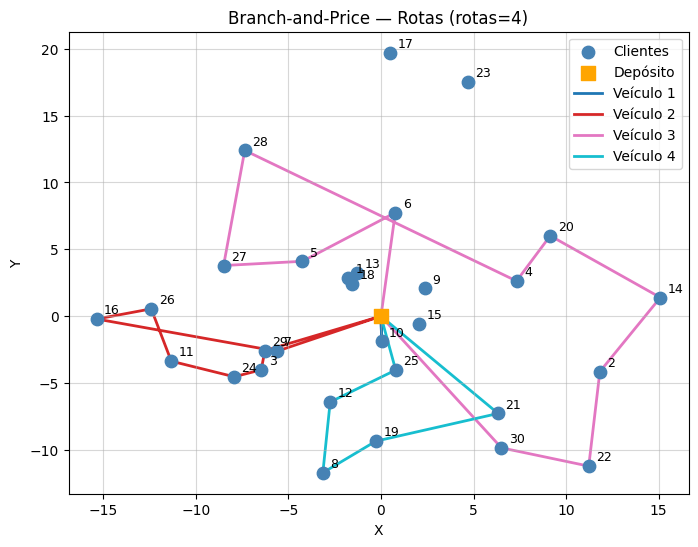

In [ ]:

# Executa B&P (igual v4)
total_routes, routes_bp = solve_column_generation(inst, max_cols=300)
print("B&P -> rotas no master:", total_routes)
if routes_bp:
    plot_routes(inst, routes_bp, title=f"Branch-and-Price — Rotas (rotas={len(routes_bp)})")
else:
    print("Nenhuma rota inteira selecionada (verificar TCs e colunas geradas).")
